# 🚗 DoorDash Delivery Prediction
## Notebook 03 — Feature Engineering

**Goal:** Create the target variable `total_delivery_duration`, engineer new features, remove collinear columns, and save to `data/features/`.

**Target Variable:**
> `total_delivery_duration_mins = actual_delivery_time - created_at` (in minutes)

**Problem Type:** Regression — predicting how long a delivery will take in minutes.

**Author:** Divyargarg

---

In [1]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── CELL 2: Load Cleaned Data ─────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f'✅ Cleaned data loaded!')
print(f'📊 Shape: {df.shape}')
print(f'\n📋 All Columns:')
for col in df.columns:
    print(f'  → {col}  ({df[col].dtype})')

✅ Cleaned data loaded!
📊 Shape: (197421, 16)

📋 All Columns:
  → market_id  (float64)
  → created_at  (str)
  → actual_delivery_time  (str)
  → store_id  (int64)
  → store_primary_category  (str)
  → order_protocol  (float64)
  → total_items  (int64)
  → subtotal  (float64)
  → num_distinct_items  (int64)
  → min_item_price  (int64)
  → max_item_price  (float64)
  → total_onshift_dashers  (float64)
  → total_busy_dashers  (float64)
  → total_outstanding_orders  (float64)
  → estimated_order_place_duration  (int64)
  → estimated_store_to_consumer_driving_duration  (float64)


## 🎯 Step 1 — Create Target Variable
`total_delivery_duration_mins = actual_delivery_time - created_at`

In [3]:
# ── CELL 3: Convert Timestamp Columns ────────────────────────────────
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

print('✅ Timestamps converted:')
print(f"  created_at           → {df['created_at'].dtype}")
print(f"  actual_delivery_time → {df['actual_delivery_time'].dtype}")
print(f'\nSample values:')
print(df[['created_at', 'actual_delivery_time']].head(3))

✅ Timestamps converted:
  created_at           → datetime64[us]
  actual_delivery_time → datetime64[us]

Sample values:
           created_at actual_delivery_time
0 2015-02-06 22:24:17  2015-02-06 23:27:16
1 2015-02-10 21:49:25  2015-02-10 22:56:29
2 2015-01-22 20:39:28  2015-01-22 21:09:09


In [4]:
# ── CELL 4: Create Target Variable ───────────────────────────────────
# total_delivery_duration = actual_delivery_time - created_at

df['total_delivery_duration'] = (
    df['actual_delivery_time'] - df['created_at']
).dt.total_seconds()

# Convert seconds → minutes for interpretability
df['total_delivery_duration_mins'] = df['total_delivery_duration'] / 60

print('✅ Target variable created!')
print(f'\n📊 Summary (minutes):')
print(df['total_delivery_duration_mins'].describe().round(2))

✅ Target variable created!

📊 Summary (minutes):
count    197421.00
mean         48.47
std         320.49
min           1.68
25%          35.07
50%          44.33
75%          56.35
max      141947.65
Name: total_delivery_duration_mins, dtype: float64


In [5]:
df.tail()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,total_delivery_duration,total_delivery_duration_mins
197416,1.0,2015-02-17 00:19:41,2015-02-17 01:24:48,2956,fast,4.0,3,1389.0,3,345,649.0,17.0,17.0,23.0,251,331.0,3907.0,65.116667
197417,1.0,2015-02-13 00:01:59,2015-02-13 00:58:22,2956,fast,4.0,6,3010.0,4,405,825.0,12.0,11.0,14.0,251,915.0,3383.0,56.383333
197418,1.0,2015-01-24 04:46:08,2015-01-24 05:36:16,2956,fast,4.0,5,1836.0,3,300,399.0,39.0,41.0,40.0,251,795.0,3008.0,50.133333
197419,1.0,2015-02-01 18:18:15,2015-02-01 19:23:22,3630,sandwich,1.0,1,1175.0,1,535,535.0,7.0,7.0,12.0,446,384.0,3907.0,65.116667
197420,1.0,2015-02-08 19:24:33,2015-02-08 20:01:41,3630,sandwich,1.0,4,2605.0,4,425,750.0,20.0,20.0,23.0,446,134.0,2228.0,37.133333


In [6]:
# ── CELL 5: Sanity Check — Remove Impossible Values ──────────────────
# Negative = delivery before order (impossible)
# > 180 mins = likely a data entry error

before = len(df)
df = df[
    (df['total_delivery_duration_mins'] > 0) &
    (df['total_delivery_duration_mins'] <= 180)
]
after = len(df)

print(f'🗑️  Removed {before - after} rows with impossible delivery times')
print(f'✅ Rows remaining: {after}')
print(f'📊 Valid range: {df["total_delivery_duration_mins"].min():.1f} → {df["total_delivery_duration_mins"].max():.1f} minutes')

🗑️  Removed 138 rows with impossible delivery times
✅ Rows remaining: 197283
📊 Valid range: 1.7 → 179.8 minutes


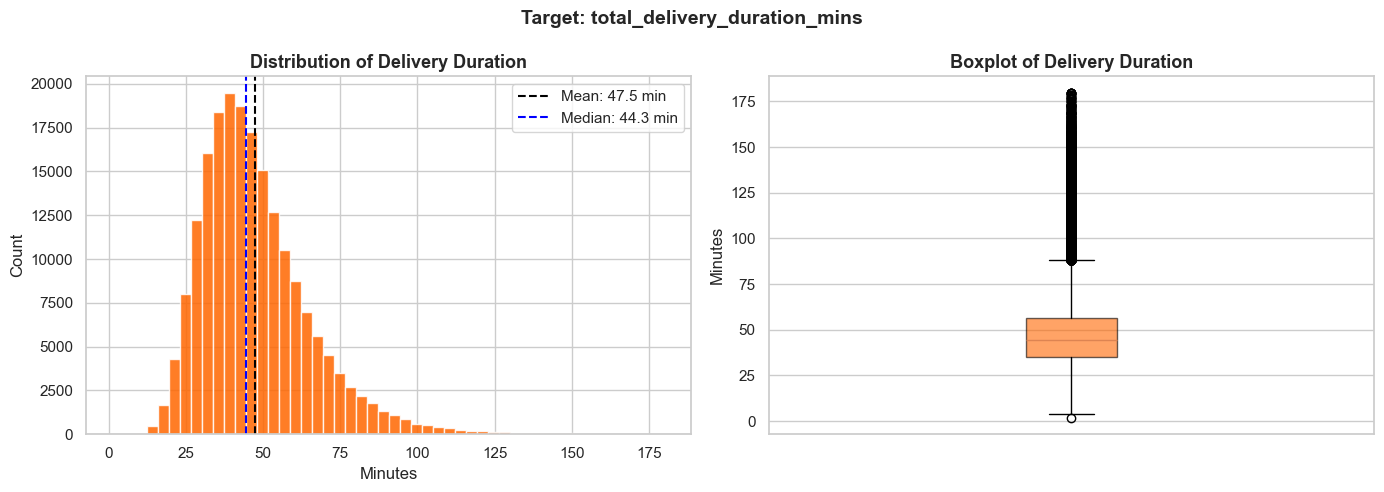

✅ Saved to outputs/figures/


In [7]:
# ── CELL 6: Visualize Target Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['total_delivery_duration_mins'], bins=50,
             color='#FF6600', edgecolor='white', alpha=0.85)
axes[0].axvline(df['total_delivery_duration_mins'].mean(), color='black',
                linestyle='--', label=f'Mean: {df["total_delivery_duration_mins"].mean():.1f} min')
axes[0].axvline(df['total_delivery_duration_mins'].median(), color='blue',
                linestyle='--', label=f'Median: {df["total_delivery_duration_mins"].median():.1f} min')
axes[0].set_title('Distribution of Delivery Duration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['total_delivery_duration_mins'], patch_artist=True,
                boxprops=dict(facecolor='#FF6600', alpha=0.6))
axes[1].set_title('Boxplot of Delivery Duration', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].set_xticks([])

plt.suptitle('Target: total_delivery_duration_mins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_target_distribution.png', dpi=150)
plt.show()
print('✅ Saved to outputs/figures/')

## ⚙️ Step 2 — Feature Engineering

In [8]:
# ── CELL 7: Time-Based Features ───────────────────────────────────────
# Extract time signals from created_at
# Rush hour, weekends, late night — all affect delivery time

df['order_hour']        = df['created_at'].dt.hour
df['order_day_of_week'] = df['created_at'].dt.dayofweek   # 0=Monday 6=Sunday
df['order_month']       = df['created_at'].dt.month
df['is_weekend']        = (df['created_at'].dt.dayofweek >= 5).astype(int)
df['is_rush_hour']      = df['created_at'].dt.hour.isin([11, 12, 13, 18, 19, 20]).astype(int)
df['is_late_night']     = df['created_at'].dt.hour.isin([22, 23, 0, 1, 2]).astype(int)

print('✅ Time features created:')
time_cols = ['order_hour', 'order_day_of_week', 'order_month', 'is_weekend', 'is_rush_hour', 'is_late_night']
print(df[time_cols].head())

✅ Time features created:
   order_hour  order_day_of_week  order_month  is_weekend  is_rush_hour  \
0          22                  4            2           0             0   
1          21                  1            2           0             0   
2          20                  3            1           0             1   
3          21                  1            2           0             0   
4           2                  6            2           1             0   

   is_late_night  
0              1  
1              0  
2              0  
3              0  
4              1  


In [9]:
# ── CELL 8: Delivery-Specific Features ───────────────────────────────

# Store to consumer estimated drive time in minutes
if 'estimated_store_to_consumer_driving_duration' in df.columns:
    df['est_store_to_consumer_mins'] = df['estimated_store_to_consumer_driving_duration'] / 60
    print('✅ est_store_to_consumer_mins created')

# Total estimated order duration in minutes
if 'estimated_order_place_duration' in df.columns:
    df['est_order_place_mins'] = df['estimated_order_place_duration'] / 60
    print('✅ est_order_place_mins created')

# How far off was the estimate from reality (estimation error)
if 'estimated_store_to_consumer_driving_duration' in df.columns:
    df['estimation_gap_secs'] = (
        df['total_delivery_duration'] - df['estimated_store_to_consumer_driving_duration']
    )
    print('✅ estimation_gap_secs created')

# Large order flag
if 'num_items' in df.columns:
    df['is_large_order'] = (df['num_items'] > df['num_items'].median()).astype(int)
    print('✅ is_large_order created')

# Price per item
if 'subtotal' in df.columns and 'num_items' in df.columns:
    df['price_per_item'] = df['subtotal'] / (df['num_items'] + 1)
    print('✅ price_per_item created')

print(f'\n📊 Total columns now: {len(df.columns)}')

✅ est_store_to_consumer_mins created
✅ est_order_place_mins created
✅ estimation_gap_secs created

📊 Total columns now: 27


In [10]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,total_delivery_duration,total_delivery_duration_mins,order_hour,order_day_of_week,order_month,is_weekend,is_rush_hour,is_late_night,est_store_to_consumer_mins,est_order_place_mins,estimation_gap_secs
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441.0,4,557,1239.0,33.0,14.0,21.0,446,861.0,3779.0,62.983333,22,4,2,0,0,1,14.350000,7.433333,2918.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900.0,1,1400,1400.0,1.0,2.0,2.0,446,690.0,4024.0,67.066667,21,1,2,0,0,0,11.500000,7.433333,3334.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,american,1.0,1,1900.0,1,1900,1900.0,1.0,0.0,0.0,446,690.0,1781.0,29.683333,20,3,1,0,1,0,11.500000,7.433333,1091.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,american,1.0,6,6387.5,5,600,1800.0,1.0,1.0,2.0,446,289.0,3075.0,51.250000,21,1,2,0,0,0,4.816667,7.433333,2786.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,american,1.0,3,3900.0,3,1100,1600.0,6.0,6.0,9.0,446,650.0,2390.0,39.833333,2,6,2,1,0,1,10.833333,7.433333,1740.0


📊 Correlations with total_delivery_duration_mins:
estimation_gap_secs                             0.9793
est_store_to_consumer_mins                      0.2374
estimated_store_to_consumer_driving_duration    0.2374
subtotal                                        0.2165
total_outstanding_orders                        0.1746
num_distinct_items                              0.1527
max_item_price                                  0.1456
total_items                                     0.1427
estimated_order_place_duration                  0.1041
est_order_place_mins                            0.1041
is_late_night                                   0.0954
total_busy_dashers                              0.0899
total_onshift_dashers                           0.0709
is_weekend                                      0.0657
order_month                                     0.0651
min_item_price                                  0.0094
order_day_of_week                               0.0008
store_id       

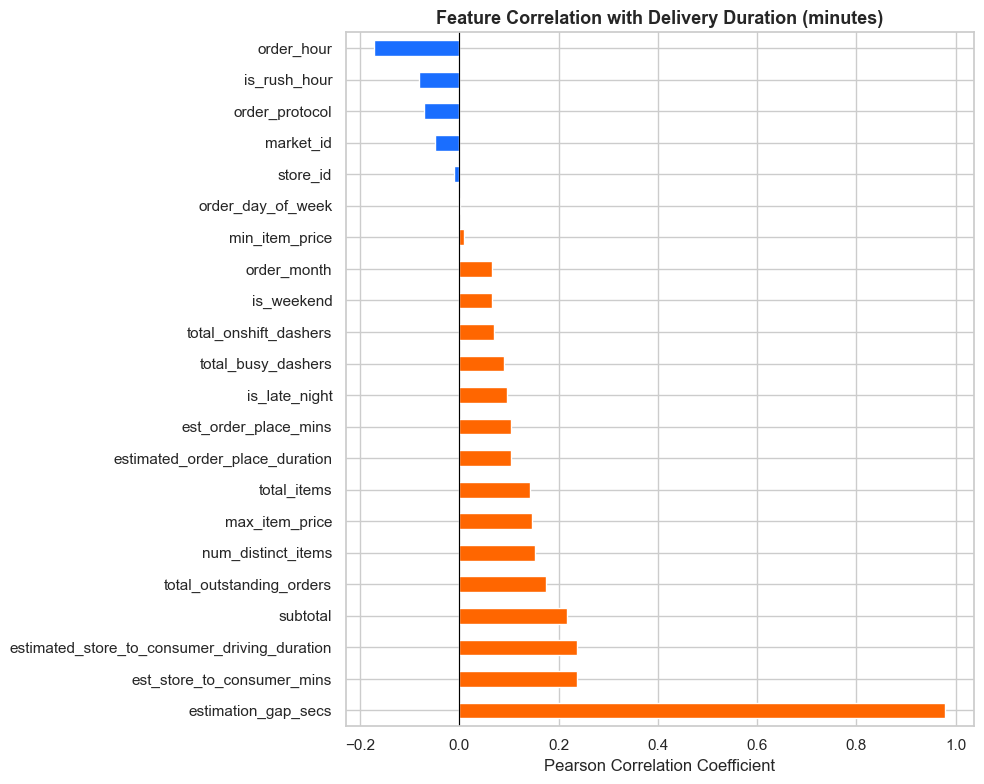

✅ Saved!


In [11]:
# ── CELL 9: Correlation of All Features with Target ───────────────────
TARGET = 'total_delivery_duration_mins'

numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = (
    numeric_df.corr()[TARGET]
    .drop(labels=[TARGET, 'total_delivery_duration'], errors='ignore')
    .sort_values(ascending=False)
)

print(f'📊 Correlations with {TARGET}:')
print(corr_with_target.round(4).to_string())

plt.figure(figsize=(10, 8))
colors = ['#FF6600' if v > 0 else '#1a6eff' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Delivery Duration (minutes)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_correlation.png', dpi=150)
plt.show()
print('✅ Saved!')

## 🔗 Step 3 — Feature Selection

In [12]:
# ── CELL 10: Drop Collinear Features (> 0.85 correlation) ─────────────
TARGET = 'total_delivery_duration_mins'

numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=[TARGET, 'total_delivery_duration'], errors='ignore'
)
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print(f'📊 Collinear columns to drop (>0.85): {to_drop}')
if to_drop:
    df = df.drop(columns=to_drop)
    print(f'✅ Dropped {len(to_drop)} collinear features')
else:
    print('✅ No highly collinear features found')

📊 Collinear columns to drop (>0.85): ['num_distinct_items', 'total_busy_dashers', 'total_outstanding_orders', 'est_store_to_consumer_mins', 'est_order_place_mins']
✅ Dropped 5 collinear features


In [13]:
# ── CELL 11: Drop Raw Timestamp & ID Columns ──────────────────────────
cols_to_drop = ['created_at', 'actual_delivery_time', 'total_delivery_duration', 'market_id', 'store_id','estimation_gap_secs']
id_cols = [col for col in df.columns if 'id' in col.lower()]
cols_to_drop += id_cols

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f'✅ Dropped: {cols_to_drop}')
print(f'\n📋 Final Feature List ({len(df.columns)} columns):')
for col in df.columns:
    tag = ' ← TARGET' if col == 'total_delivery_duration_mins' else ''
    print(f'  → {col}{tag}')

✅ Dropped: ['created_at', 'actual_delivery_time', 'total_delivery_duration', 'market_id', 'store_id', 'estimation_gap_secs', 'market_id', 'store_id']

📋 Final Feature List (16 columns):
  → store_primary_category
  → order_protocol
  → total_items
  → subtotal
  → min_item_price
  → max_item_price
  → total_onshift_dashers
  → estimated_order_place_duration
  → estimated_store_to_consumer_driving_duration
  → total_delivery_duration_mins ← TARGET
  → order_hour
  → order_day_of_week
  → order_month
  → is_weekend
  → is_rush_hour
  → is_late_night


In [14]:
# ── CELL 12: Save Feature Data ────────────────────────────────────────
df.to_csv('../data/features/features_data.csv', index=False)
print('✅ Saved to data/features/features_data.csv')
print(f'📊 Final shape: {df.shape}')

✅ Saved to data/features/features_data.csv
📊 Final shape: (197283, 16)


## 📝 Feature Engineering Notes
*(Copy key decisions to docs/decisions.md too)*

- **Target:** `total_delivery_duration_mins = actual_delivery_time - created_at` (minutes)
- **Rows removed (impossible values):** 
- **New features added:** 
- **Features dropped (collinearity):** 
- **Most correlated with target:** 
- **Ideas to try next:** 